# Assignment 10

### <span style="color:chocolate"> Submission requirements </span>

Your work will not be graded if your notebook doesn't include output. In other words, <span style="color:red"> make sure to rerun your notebook before submitting to Gradescope </span> (Note: if you are using Google Colab: go to Edit > Notebook Settings  and uncheck Omit code cell output when saving this notebook, otherwise the output is not printed).

Additional points may be deducted if these requirements are not met:
    
* Comment your code;
* Each graph should have a title, labels for each axis, and (if needed) a legend. Each graph should be understandable on its own;
* Try and minimize the use of the global namespace (meaning, keep things inside functions).

---

#### ``Objectives``
1. Implement a CNN to detect diabetic retinopathy (DR) from retina images taken using fundus photography under a variety of imaging conditions.
2. Improve generalization performance and reduce overfitting using **image transformation** and **data augmentation** techniques.

#### ``Motivation``

Diabetic retinopathy (DR) is an eye condition that  affects blood vessels in the retina. It can cause vision loss and blindness in people who have diabetes. Screening for DR allows earlier and more effective treatment options for millions of people.

#### ``Data``

In this assignment you will use a small dataset of retina images (`Download` links: [images](https://drive.google.com/drive/folders/1sdfUC64Un1iwuiHEehcbijxB54OhU_nd?usp=sharing) and [labels](https://drive.google.com/drive/folders/1MOlSJBZg7L1HtG5vHPt77ighRvQaGfDg?usp=sharing)). You will **build** and **train** a **CNN model** to predict whether or not to refer a patient for DR treatment using binarized severity of DR in patients: no referral if {No DR, mild} and referral if {moderate, severe, and proliferate DR}.


<u>Note</u>: the original dataset is hosted by Kaggle [[Source]](https://www.kaggle.com/c/aptos2019-blindness-detection/).

Import the necessary libraries and make sure to replace IMAGE_PATH and LABEL_PATH with the path to the directories where you saved the data.

---
### Step 1: Import libraries

In [146]:
# standard
import pandas as pd
import numpy as np
import random
import os

# tf and keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator, array_to_img, img_to_array, load_img
from keras import models
from keras import layers

# sklearn
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# plots
import seaborn as sns
import matplotlib.pyplot as plt

random.seed(2)
%matplotlib inline

# FILL IN CODE HERE #
IMAGE_PATH = 'datasets/CNN_images/' # replace with your path
LABEL_PATH = 'datasets/' # replace with your path

At this point, you may ask yourself what the best model that fits this data is. First, you will want to read through the data description in Kaggle (see the link to the original dataset above). Understanding what you are working with challenges you to write preprocessing code that uncovers your data's most helpful information.

---
#### <span style="color:chocolate"> Exercise 1 (10 points) </span>

Read the data description from Kaggle and list (a) the source of images and (b) the labeling procedure.

*Written answer*: Aravind Eye Hospital technicians travel to rural areas in India and take retinal images of people's eyes, then rely on highly trained doctors to label the images as a 1-5 scale from No DR ... Proliferate DR. Those images from Aravind Eye Hospital technicians are the images and the doctors labels are the labels.

---
### Step 2: Data ingestion

Let's load the 2D images and their corresponding labels.

``labels``

In [147]:
labels = pd.read_csv(
    LABEL_PATH + 'labels.csv'
)

print('Shape of labels:', labels.shape)
print('Unique diagnosis codes:', np.sort(labels.diagnosis.unique()))
labels.head()

Shape of labels: (200, 2)
Unique diagnosis codes: [0 1 2 3 4]


,id_code,diagnosis
0,000c1434d8d7,2
1,0024cdab0c1e,1
2,0083ee8054ee,4
3,00a8624548a9,2
4,00b74780d31d,2


There are 200 training images corrresponding to 5 different diabetic retinopathy (DR) diagnosis codes: 

* No DR (0)
* mild (1)
* moderate (2)
* severe (3)
* proliferate DR (4)


``images``

In [148]:
images = []

for idx, img in enumerate(os.listdir(IMAGE_PATH)):
    img = load_img(
    IMAGE_PATH + img)
    images.append(img)

---
### Step 3: Exploratory Data Analysis (EDA)

#### <span style="color:chocolate"> Exercise 2 (10 points) </span>

Plot a histogram for the five classes of DR. Are the classes balanced?


Note: It's acceptable to plot the distribution of classes before splitting your data into training, validation, and test sets. Doing so does not compromise the "blindness" of the test data. Why?

In [149]:
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_code    200 non-null    object
 1   diagnosis  200 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 3.2+ KB


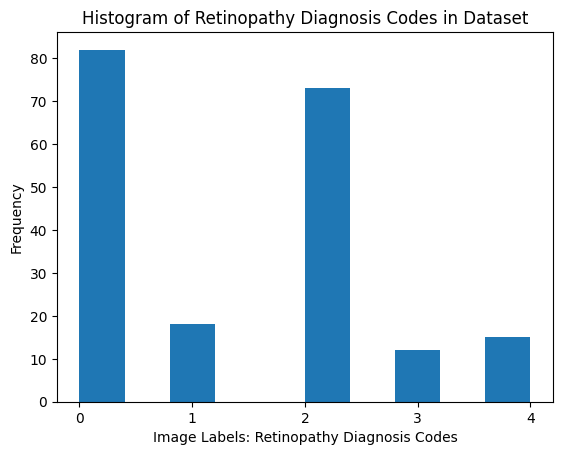

In [150]:
plt.hist(labels["diagnosis"])
plt.xlabel("Image Labels: Retinopathy Diagnosis Codes")
plt.xticks(range(5))
plt.ylabel("Frequency")
plt.title("Histogram of Retinopathy Diagnosis Codes in Dataset")
plt.show()

Comment on class balance: Looking at overall class distribution does not compromise blindness of test data because we are only looking at target variable distribution, we are not introducing bias that could leave to overfitting just by getting a sense of distribution of target variable. We may be getting helpful information on how to stratify our train test split if there is strange class imbalance which could be important for model architecture later, but we are not doing any analytical steps that will actually lead to overfitting, which is the main concern with peaking at your test set data. If we did analytical or feature engineering work that directly caused us to fit our training data too closely to our test set data, that would bias the accuracy scores of our model, but just getting a look at potential class imbalance as an inborn feature of our data could help us get a sense of what the data typically looks like. If we looked at only our test set and learned patterns of that test set, then based our model architecture off of "over-fitting" to test set, that would be bad and would undoubtedly lead to poor generalizability in the deployment phase as it was used to look at real world data. But we will not do that, we will just look at overall, eventual train and test set, distribution without knowing what our exact test set will contain. 

#### <span style="color:chocolate"> Exercise 3 (10 points) </span>

Print 8 images from the data. What can you say about the size, focus/orientation of these images?

In [151]:
first_8_images

[<PIL.PngImagePlugin.PngImageFile image mode=RGB size=3388x2588>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=2588x1958>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1504x1000>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1050x1050>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=2588x1958>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=3388x2588>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=819x614>,
 <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1050x1050>]

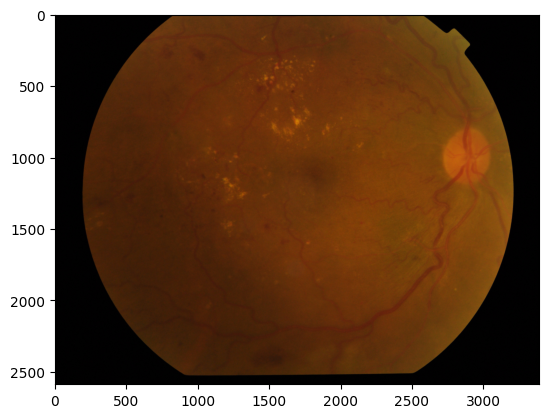

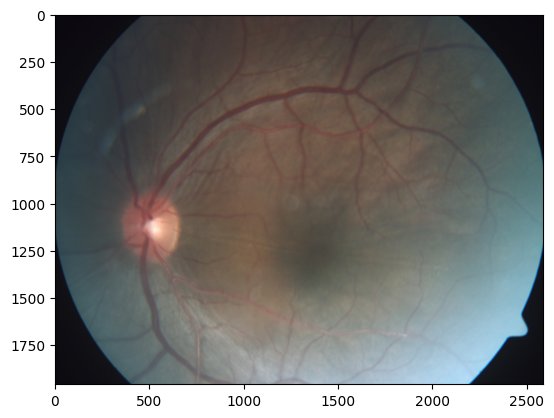

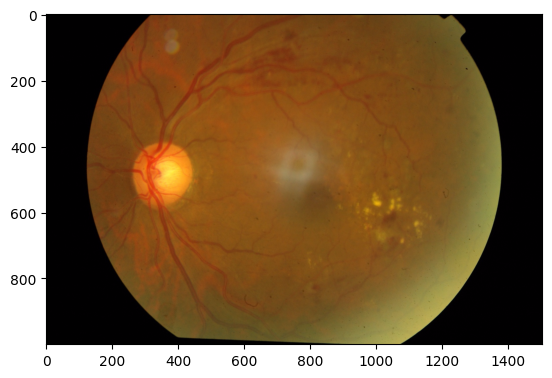

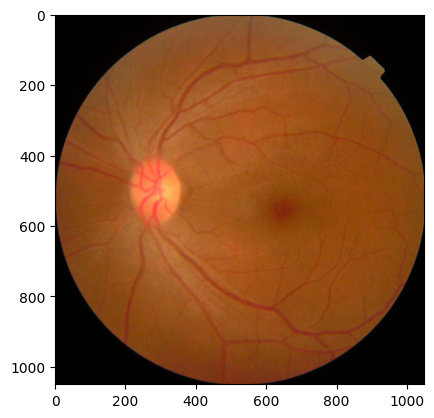

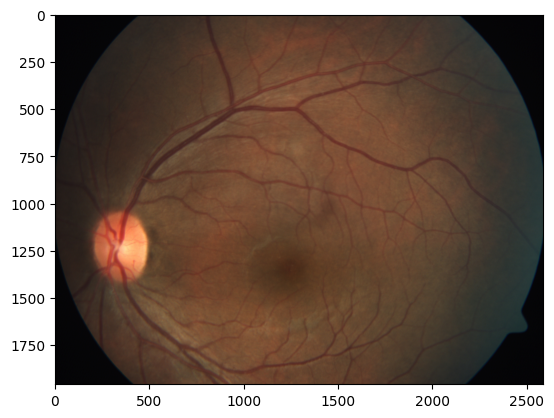

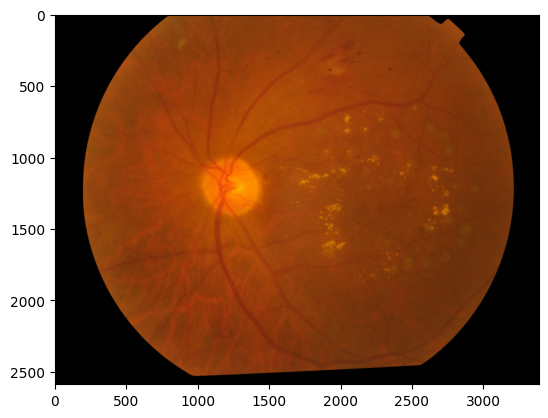

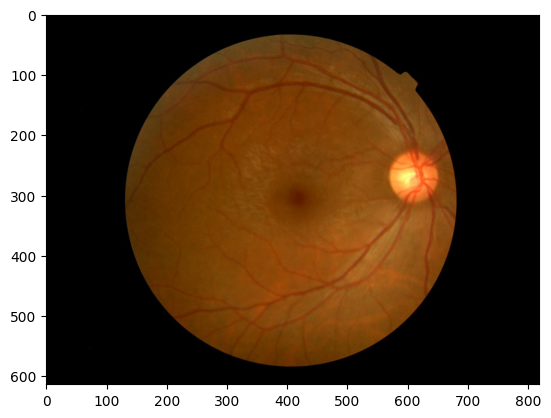

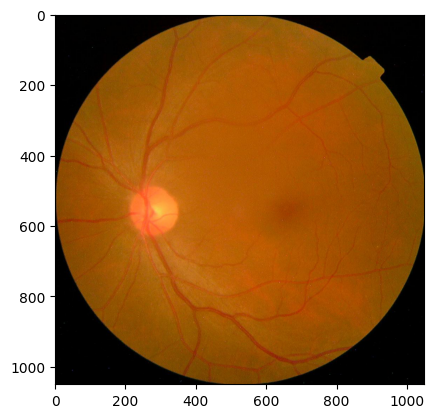

In [152]:
first_8_images = images[:8]

for image in first_8_images:
    plt.imshow(image)
    plt.show()
    

Comment on the size, focus/orientation of the 8 images: The images are all different sizes and the focus light, spot-light part, is in different locations in each image. So this is a good fit for CNN because the important part of each image is in different spots on each image so we will want our model to "condense" the images to learn the important part, the spotlight, in different parts of the image, we can't train the model on ~140 images to only focus on the same pixels because pixel count and pixel location we should focus on is in different spots in each image.

---
### Step 4: Data preprocessing

First, we will correct for class imbalance. Note that imbalanced data is common in healthcare, and it happens because some diseases are rare. The presence of imbalanced data hampers the detection of rare events as most classification methods implicitly assume a similar occurrence of classes and are designed to maximize the overall classification accuracy.

We will correct for class imbalance in two ways:

  * First, we will binarize the DR diagnosis as follows:
     - 'no refer' are {No DR, mild}
     - 'refer' are {Moderate, Severe, Proliferate}


  * Second, we'll only take 80 random samples from the 'no refer' class and 80 from the 'refer' class.

It is a crude method to deal with imbalanced data, but it will be good enough for this homework. 

In [153]:
np.random.seed(1234)

no_refer = labels[labels.diagnosis.isin((0,1))]
refer = labels[labels.diagnosis.isin((2,3,4))]

# randomly draw 80 images from each classes
temp_no_refer = list(np.random.choice(
    no_refer.id_code,
    size=80,
    replace=False
))

temp_refer = list(np.random.choice(
    refer.id_code,
    size=80,
    replace=False
))

Next, we will use the ``preprocess_data_part1()`` function defined below to generate lists of images and labels (images_mini and y_mini) based on the values in the temp_no_refer and temp_refer lists. Note that the size of the image is set to (224, 224).

In [154]:
def preprocess_data_part1(IMAGE_PATH, LABEL_PATH, temp_no_refer, temp_refer):
    """ Generate lists of images and labelsbased on temp_no_refer and temp_refer lists
    
    Params:
    -------
    IMAGE_PATH (str): path to directory with images.
    LABEL_PATH (str): path to directory with labels.
    temp_no_refer (str): list of labels for the no refer category
    temp_refer (str): list of labels for the refer category
    
    Returns:
    --------
    images_mini  (np.ndarray): Images of shape (N, 224, 224, 3)
    y_mini (np.ndarray): Labels of shape (N,)    
    """
    y_mini = []
    images_mini = []

    # create lists of images and labels `images_mini` and `y_mini` 
    # based on temp_no_refer and temp_refer selections
    for idx, img in enumerate(os.listdir(IMAGE_PATH)):
        # read labels
        if img.split('.')[0] in temp_no_refer:
                y_mini.append(0)
        elif img.split('.')[0] in temp_refer:
                y_mini.append(1)
        else:
            continue

        
        # read image
        img = load_img(
            IMAGE_PATH + img,
            target_size=(224, 224)
        )
        
        # transform image to array
        img = img_to_array(img)

        # append to images
        images_mini.append(img)

    # stack images and trasnform to array
    images_mini = np.stack(images_mini)
    y_mini = np.array(y_mini).flatten() 
    
    return images_mini, y_mini

In [155]:
# generate images and labels based on preprocess_data_part1() function
images_mini, y_mini = preprocess_data_part1(
    IMAGE_PATH, LABEL_PATH, temp_no_refer, temp_refer
)

print(f"images_mini shape {images_mini.shape}")
print(f"y_mini shape {y_mini.shape}")

images_mini shape (160, 224, 224, 3)
y_mini shape (160,)


#### <span style="color:chocolate"> Exercise 4 (20 points) </span>

Create train, validation, and test data. Implement the `preprocess_data_part2()` function according to the following guidelines:

1. shuffle images and labels before splitting the data

2. use a (0.6,0.2,0.2)train/validation/test set split

3. perform image transformation and augmentation, as follows:
    * Applied on training set only:
         - create additional copies (augmentations) of the training images by flipping left right each image (Hint: use the method available in the tf.image module).
         - concatenate the augmented images to the original training images. Note that the train set should be double in size after data augmentation, i.e., 192 images and labels.
    * Applied on training, validation, and test sets:
        - rescale images by dividing each pixel by 255.0

Reason for doing image augmentation: The quantity and diversity of data gathered significantly impact the results of a CNN model. One can use augmentations to artificially inflate the training dataset by warping the original data so that their label does not change. These augmentations can significantly improve learning results without collecting new data.

In [156]:
def preprocess_data_part2(images, labels, splits):
    """ Split data into train, validation and test sets; apply transformaions and augmentations
    
    Params:
    -------
    images  (np.ndarray): Images of shape (N, 224, 224, 3)
    labels (np.ndarray): Labels of shape (N,)   
    splits (tuple): 3 values summing to 1 defining split of train, validation and test sets
    
    Returns:
    --------
    X_train (np.ndarray): Train images of shape (N_train, 224, 224, 3)
    y_train (np.ndarray): Train labels of shape (N_train,)
    X_val (np.ndarray): Val images of shape (N_val, 224, 224, 3)
    y_val (np.ndarray): Val labels of shape (N_val,)
    X_test (np.ndarray): Test images of shape (N_test, 224, 224, 3)
    y_test (np.ndarray): Test labels of shape (N_test,)
    
    """
    
    # NOTE: Each time you run this cell, you'll re-shuffle the data. The ordering will be the same due to the random seed generator 
    tf.random.set_seed(1234)
    np.random.seed(1234)
    
    # shuffle data
    indices = tf.range(start=0, limit = tf.shape(images)[0])
    shuffled_indices = tf.random.shuffle(indices)

    images = images[shuffled_indices]
    labels = labels[shuffled_indices]
    
    # create data splits (training, val, and test sets)
    from sklearn.model_selection import train_test_split
    X_train, X_temp, y_train, y_temp = train_test_split(images, labels, train_size = splits[0], test_size = splits[1] + splits[2])
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=splits[2])
    
    # image augmentation (random flip) on training data
    X_train_augm = tf.image.flip_left_right(X_train)

    # concatenate original X_train and augmented X_train_augm data
    X_train = tf.concat([X_train, X_train_augm],axis=0)

    # concatenate y_train (note the label is preserved)
    y_train_augm = y_train
    y_train = tf.concat([y_train, y_train_augm],axis=0)

    # shuffle X_train and y_train, i.e., shuffle two tensors in the same order
    shuffle = tf.random.shuffle(tf.range(tf.shape(X_train)[0], dtype=tf.int32))
    X_train = tf.gather(X_train, shuffle).numpy() # transform X back to numpy array instead of tensor
    y_train = tf.gather(y_train, shuffle).numpy() # transform y back to numpy array instead of tensor

    # rescale training, val, and test images by dividing each pixel by 255.0 
    X_train = X_train / 255.0
    X_val = X_val / 255.0
    X_test = X_test / 255.0
    
    return X_train, y_train, X_val, y_val, X_test, y_test

In [157]:
# define splits
split = (0.6, 0.2, 0.2)

X_train, y_train, X_val, y_val, X_test, y_test = preprocess_data_part2(
    images_mini,
    y_mini,
    split
)

print(f"X_train shape {X_train.shape}")
print(f"y_train shape {y_train.shape}")
print(f"X_val shape {X_val.shape}")
print(f"y_val shape {y_val.shape}")
print(f"X_test shape {X_test.shape}")
print(f"y_test shape {y_test.shape}")

X_train shape (192, 224, 224, 3)
y_train shape (192,)
X_val shape (51, 224, 224, 3)
y_val shape (51,)
X_test shape (13, 224, 224, 3)
y_test shape (13,)


---
### Step 5: Modeling

#### <span style="color:chocolate"> Exercise 5 (20 points) </span>

The objective is to build and train a CNN model to refer patients to doctors based on the severity of DR seen in these images. You are interested in exploring binary classification of 'no refer' and 'refer'.

Implement a CNN classifier according to the following guidelines (let's call this *model_tf*):

1. Implement this model using the TF Keras API.
1. The model receives input images of size 224 x 224 x 3 (that is, the images have three color channels)
2. The input data goes through one convolutional layer that has the following specifications:
    - filters = 12
    - kernel_size = (4 x 4)
    - strides = (1, 1)
    - padding = 'same'
    - data_format = 'channels_last'
    - name = 'conv_1'
    - activation = 'relu'
3. The convolutional layer is followed by a max-pooling layer with pool_size = (2,2). Note: this will reduce the size of the feature maps.
4. The max-pooling layer is followed by a dropout layer with rate = 0.3.
5. The dropout layer is followed by a flattening layer.
6. The last layer of the model is the classification head.
7. Build and compile the model using the Adam optimizer and learning_rate = 0.1. Print summary of the model.
8. Train the model on (X_train, y_train) data for 20 epochs. Add early stopping (Hint: pass the early_stopping implementation below to the fit() method as "callbacks=[early_stopping]").
9. How many parameters does the model have?
10. Generate a plot (for the training and validation data) with the loss values on the y-axis and the epoch number on the x-axis for visualization. Make sure to include axes name and title. Hint: check what the tf.keras.Model.fit() method returns.
11. Evaluate the accuracy of the model on (X_train, y_train) and (X_val, y_val) data. Comment on model performance on training vs. validation datasets. 

In [158]:
# define an instance of the early_stopping class
early_stopping = tf.keras.callbacks.EarlyStopping(
monitor='accuracy', 
verbose=1,
patience=5,
mode='max',
restore_best_weights=True)

Model: "sequential_50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 224, 224, 12)   │           588 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_55 (MaxPooling2D) │ (None, 112, 112, 12)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 112, 112, 12)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_47 (Flatten)            │ (None, 150528)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 1)              │       150,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151,117 (590.30 KB)

 Trainable params: 151,117 (590.30 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.4688 - loss: 8.4199 - val_accuracy: 0.4902 - val_loss: 8.1275
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4896 - loss: 8.1373 - val_accuracy: 0.4902 - val_loss: 8.1275
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4896 - loss: 8.1373 - val_accuracy: 0.4902 - val_loss: 8.1275
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4896 - loss: 8.1373 - val_accuracy: 0.4902 - val_loss: 8.1275
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4896 - loss: 8.1373 - val_accuracy: 0.4902 - val_loss: 8.1275
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4896 - loss: 8.1373 - val_accuracy: 0.4902 - val_loss: 8.1275
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4896 - loss: 8.1373 - val_accuracy: 0.4902 - val_loss: 8.1275
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.


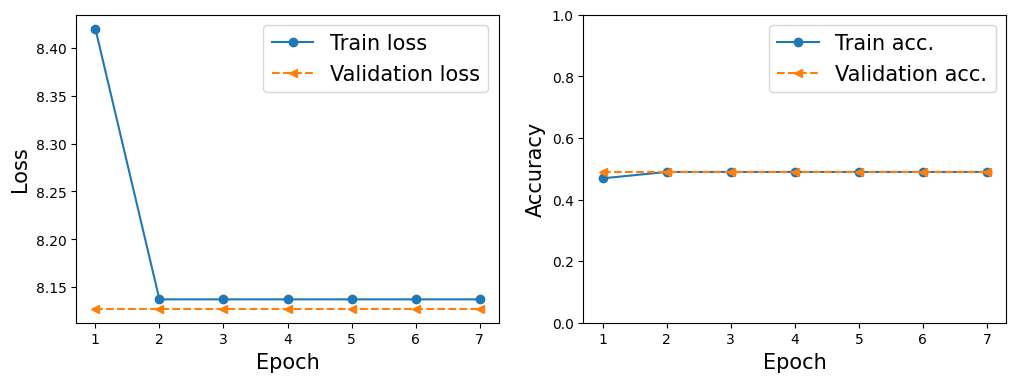

After training this model for 20 epochs, evaluation on the training data shows an accuracy of:
48.96 %
After training this model for 20 epochs, evaluation on the validation data shows an accuracy of:
49.02 %


In [159]:

tf.random.set_seed(1234)
np.random.seed(1234)

# initialize model
model_tf = tf.keras.Sequential()

# add convolutional layer
model_tf.add(layers.Conv2D(filters = 12,
    kernel_size = (4 , 4),
    strides = (1, 1),
    padding = 'same',
    data_format = 'channels_last',
    name = 'conv_1',
    activation = 'relu'))

# add max pooling layer 
model_tf.add(layers.MaxPool2D(pool_size=(2,2)))

# add dropout layer
model_tf.add(layers.Dropout(rate=0.3))

# add a flattening layer
model_tf.add(layers.Flatten())

# add the classification layer
model_tf.add(layers.Dense(1))

# build and compile model
model_tf.build(input_shape=(None, 224, 224, 3))
model_tf.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy']) 

# print model_tf summary
model_tf.summary()

# train model_tf on (X_train, y_train) data
history = model_tf.fit(X_train, y_train,
                       validation_data=(X_val, y_val), 
                       epochs=20, 
                       callbacks=[early_stopping])

# plot loss curves
hist = history.history
x_arr = np.arange(len(hist['loss'])) + 1

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist['loss'], '-o', label='Train loss')
ax.plot(x_arr, hist['val_loss'], '--<', label='Validation loss')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Loss', size=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist['accuracy'], '-o', label='Train acc.')
ax.plot(x_arr, hist['val_accuracy'], '--<', label='Validation acc.')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Accuracy', size=15)
ax.set_ylim(0,1)
plt.show()

# evaluate the accuracy of model_tf on (X_train, y_train) and (X_val, y_val)
print('After training this model for 20 epochs, evaluation on the training data shows an accuracy of:')
print(np.round(hist['accuracy'][-1]*100,2), '%')
print('After training this model for 20 epochs, evaluation on the validation data shows an accuracy of:')
print(np.round(hist['val_accuracy'][-1]*100,2), '%')

How many parameters does *model_tf* have? 151,117 parameters

Comment on *model_tf* accuracy on training vs. validation data: The validation accuracy is the same as training accuracy, and they are both pretty bad, below 50% accurate, which basically means they are right half the time which could be just due to chance. It seems like even a majority classifier would do better at predicting retinal issues, maybe this is due to class imbalance. 

#### <span style="color:chocolate"> Exercise 6 (20 points) </span>

1. Fine-tune the number of hidden layers and the hyperparameters of *model_tf* to determine the setup that yields the most optimal generalization performance. Feel free to explore various model configurations/hyperparameter values.

2. How many parameters does your fine-tuned model have?

3. Evaluate the accuracy of the fine-tuned model on (X_train, y_train) and (X_val, y_val) data. Comment on model performance on training vs. validation datasets.  Is there an improvement compared to the non-fine-tuned version of the model (Exercise 5)?

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 112, 112, 24)   │         4,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 56, 56, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 56, 56, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 28, 28, 24)     │         9,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4704)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       301,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,057 (1.20 MB)

 Trainable params: 315,057 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.4688 - loss: 8.0776 - val_accuracy: 0.4902 - val_loss: 8.1275
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4896 - loss: 8.1373 - val_accuracy: 0.4902 - val_loss: 8.1275
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4896 - loss: 8.1373 - val_accuracy: 0.4902 - val_loss: 8.1275
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4896 - loss: 8.1373 - val_accuracy: 0.4902 - val_loss: 8.1275
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4896 - loss: 8.1373 - val_accuracy: 0.4902 - val_loss: 8.1275
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


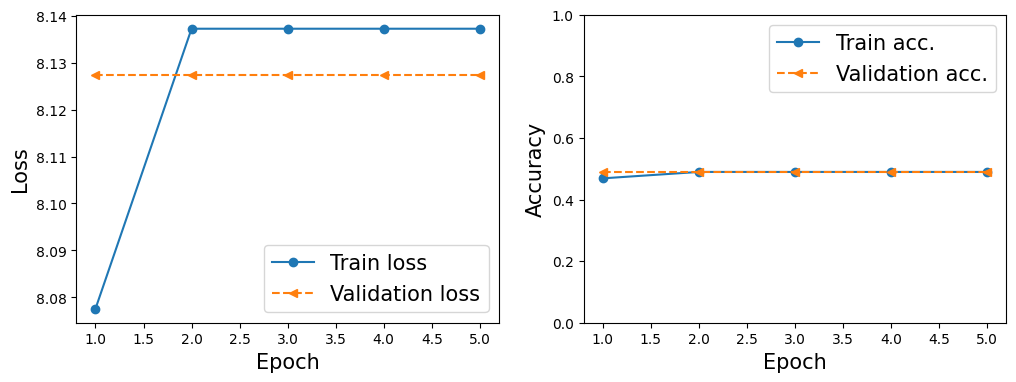

After training this model for 20 epochs, evaluation on the training data shows an accuracy of:
48.96 %
After training this model for 20 epochs (with early stopping), evaluation on the validation data shows an accuracy of:
49.02 %


In [167]:
tf.random.set_seed(1234)
np.random.seed(1234)

tf.keras.backend.clear_session()
# initialize model
model_tf_2 = tf.keras.Sequential()

# add convolutional layer 
model_tf_2.add(layers.Conv2D(filters = 24,
    kernel_size = (8 , 8),
    strides = (2, 2),
    padding = 'same',
    data_format = 'channels_last',
    name = 'conv_1',
    activation = 'relu'))

# add max pooling layer 
model_tf_2.add(layers.MaxPool2D(pool_size=(2,2)))

# add dropout layer
model_tf_2.add(layers.Dropout(rate=0.3))

# add convolutional layer -
model_tf_2.add(layers.Conv2D(filters = 24,
    kernel_size = (4 , 4),
    strides = (2, 2),
    padding = 'same',
    data_format = 'channels_last',
    name = 'conv_2',
    activation = 'relu'))

# add max pooling layer 
model_tf_2.add(layers.MaxPool2D(pool_size=(2,2)))

# add dropout layer
#model_tf_2.add(layers.Dropout(rate=0.3))

# add a flattening layer
model_tf_2.add(layers.Flatten())

# Adding another dense layer to improve performance
model_tf_2.add(layers.Dense(64, activation="relu"))

# add the classification layer
model_tf_2.add(layers.Dense(1))

# build and compile model
model_tf_2.build(input_shape=(None, 224, 224, 3))
model_tf_2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=['accuracy']) 

# print model_tf summary
model_tf_2.summary()

# train model_tf on (X_train, y_train) data
history = model_tf_2.fit(X_train, y_train,
                       validation_data=(X_val, y_val), 
                       epochs=20, 
                       callbacks=[early_stopping])

# plot loss curves
hist = history.history
x_arr = np.arange(len(hist['loss'])) + 1

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist['loss'], '-o', label='Train loss')
ax.plot(x_arr, hist['val_loss'], '--<', label='Validation loss')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Loss', size=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist['accuracy'], '-o', label='Train acc.')
ax.plot(x_arr, hist['val_accuracy'], '--<', label='Validation acc.')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Accuracy', size=15)
ax.set_ylim(0,1)
plt.show()

# evaluate the accuracy of model_tf on (X_train, y_train) and (X_val, y_val)
print('After training this model for 20 epochs, evaluation on the training data shows an accuracy of:')
print(np.round(hist['accuracy'][-1]*100,2), '%')
print('After training this model for 20 epochs (with early stopping), evaluation on the validation data shows an accuracy of:')
print(np.round(hist['val_accuracy'][-1]*100,2), '%')

How many parameters does your fine-tuned model have? 315,057 parameters

Comment on accuracy of the fine-tuned model on training vs. validation performance. Is there an improvement over the non-fine-tuned version?  I tried changing the number of filters, kernel size and strides, adding another convolutional layer with max pooling and dropout, and adding a dense layer, plus increasing the learning rate t0 0.2. The accuracy on validation dataset did not change- I couldn't get it to budge after trying many things and adding more model complexity. The loss is increaseing which is very confusing to me- that should not be happening, possibly my model is getting stuck in a local minimum on my feature graph and is trying unsuccessfuly to crawl out. Based on this hypothesis, I tried to remove early stopping but it made no difference. Maybe this dataset is especially tough or a conv neural net is not the best classifier due to class imbalance. This is not much but it's something- I tried many versions of changing the kernel and stride to get my convolutional layer to more accurately find the spotlight area where the retinal problem existed but most tweaks I made gave me the same validation accuracy as the previous model.

---
### Step 6: Evaluation

#### <span style="color:chocolate"> Exercise 7 (10 points) </span>

You will now use the test data to evaluate the performance (accuracy) of your fine-tuned model on unseen data. Does your model generalize well?

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.6154 - loss: 6.1317
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6154 - loss: 6.1317
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6154 - loss: 6.1317
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6154 - loss: 6.1317
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6154 - loss: 6.1317
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


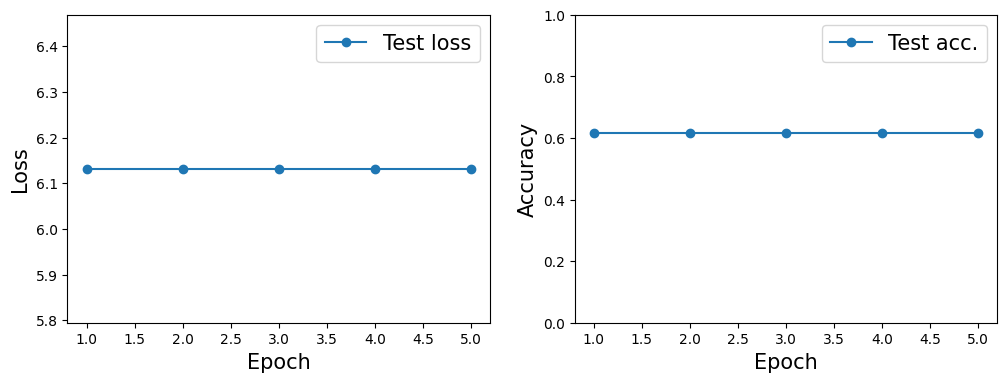

After training this model for 20 epochs (with early stopping), evaluation on the test data shows an accuracy of:
61.54 %


In [168]:
# train model_tf on (X_train, y_train) data
history = model_tf_2.fit(X_test, y_test, 
                       epochs=20, 
                       callbacks=[early_stopping])

# plot loss curves
hist = history.history
x_arr = np.arange(len(hist['loss'])) + 1

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist['loss'], '-o', label='Test loss')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Loss', size=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist['accuracy'], '-o', label='Test acc.')
ax.legend(fontsize=15)
ax.set_xlabel('Epoch', size=15)
ax.set_ylabel('Accuracy', size=15)
ax.set_ylim(0,1)
plt.show()

# evaluate the accuracy of model_tf on (X_train, y_train) and (X_val, y_val)
print('After training this model for 20 epochs (with early stopping), evaluation on the test data shows an accuracy of:')
print(np.round(hist['accuracy'][-1]*100,2), '%')

Does your model generalize well? Somewhat well, actually! I'm not sure how but test accuracy improved quite a but- juping above 60% accuracy on test data which is unseen, so maybe my improved model is a little better than I thought. We care most about model preformance on the test set so it's good the test accuracy is high but i don't quite understand why it didn't change on training and validation data after model tweaks.